In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [9]:
df=pd.read_csv("SalaryGrowth.csv")
df.head()


,Years of Experience,Number of Projects,Salary
0,1,1,25000
1,2,2,30000
2,3,2,35000
3,4,3,45000
4,5,3,50000


In [10]:
df.dtypes

Years of Experience    int64
Number of Projects     int64
Salary                 int64
dtype: object

In [11]:
df.isnull().sum()

Years of Experience    0
Number of Projects     0
Salary                 0
dtype: int64

In [14]:
y=df[['Salary']]
x=df[['Years of Experience','Number of Projects']]


   Years of Experience  Number of Projects
0                    1                   1
1                    2                   2
2                    3                   2
3                    4                   3
4                    5                   3
5                    6                   4
6                    7                   4
7                    8                   5
8                    9                   5
9                   10                   6
   Salary
0   25000
1   30000
2   35000
3   45000
4   50000
5   60000
6   65000
7   75000
8   80000
9   90000


In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)

In [19]:
model=LinearRegression()
model.fit(x_train,y_train)
y_pred_line=model.predict(x_test)
y_pred_line


array([[79310.34482759],
       [32068.96551724],
       [60517.24137931]])

In [22]:
degree=2
poly=PolynomialFeatures(degree=degree)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.fit_transform(x_test)

model_poly=LinearRegression()
model_poly.fit(x_train_poly,y_train)
y_pred_poly=model_poly.predict(x_test_poly)
y_pred_poly


array([[81304.34782609],
       [33260.86956522],
       [58913.04347826]])

In [33]:
Linear_MSE=mean_squared_error(y_test,y_pred_line)
print("Linear MSE=",Linear_MSE)

Polynomial_MSE=mean_squared_error(y_test,y_pred_poly)
print("Polynomial MSE",Polynomial_MSE)

if Linear_MSE < Polynomial_MSE:
    print("Linear Model is better!")
else:
    print("Polynomial Model is better!")

Linear MSE= 1674593.7376139546
Polynomial MSE 4505356.017643432
Linear Model is better!


In [34]:
from sklearn.neighbors import KNeighborsClassifier


In [36]:
df=pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [39]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [40]:
df['Purchased'].unique()

array([0, 1])

In [41]:
df=pd.get_dummies(df,drop_first=True)

In [42]:
y=df[['Purchased']]

In [63]:
x=df.drop(['Purchased',"User ID"],axis=1)
y

,Purchased
0,0
1,0
2,0
3,0
4,0
...,...
395,1
396,1
397,1
398,0


In [47]:
x.head()

,Age,EstimatedSalary,Gender_Male
0,19,19000,True
1,35,20000,True
2,26,43000,False
3,27,57000,False
4,19,76000,True


In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=70)

In [49]:
x_train

,Age,EstimatedSalary,Gender_Male
206,55,130000,False
124,41,51000,False
310,42,70000,False
137,30,107000,True
227,56,133000,True
...,...,...,...
316,54,104000,False
280,59,88000,False
114,42,80000,True
214,47,43000,True


In [58]:
KNN=KNeighborsClassifier(n_neighbors=3)
KNN.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [59]:
y_pred=KNN.predict(x_test)
y_pred

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0])

In [60]:
prediction=pd.DataFrame({
    'actual':y_test.squeeze(),
    'pred':y_pred.squeeze()
})

In [61]:
prediction

,actual,pred
283,1,1
74,0,0
292,1,1
150,0,0
311,1,1
...,...,...
112,0,0
38,0,0
302,1,1
65,0,0


In [65]:
# Age:25 Salary:3000 gender: femal
x_new=[[25,30000,False]]
y_new=KNN.predict(x_new)
if y_new==1:
    print('Purchsed')
else:
    print('Not Purchased')

Purchsed


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [66]:
from sklearn.metrics import confusion_matrix

In [68]:
conf_matrix=confusion_matrix(y_test,y_pred)
conf_matrix

array([[45, 11],
       [ 3, 21]])

Text(50.722222222222214, 0.5, 'Actual')

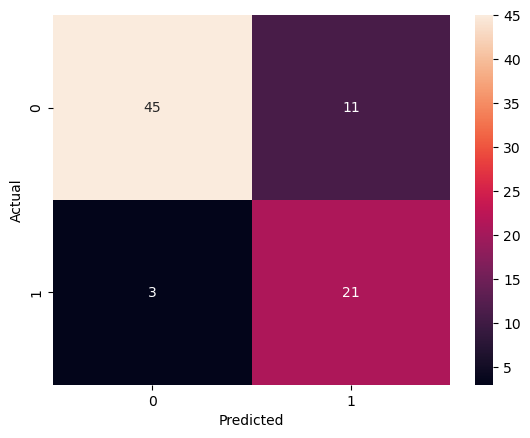

In [69]:
sns.heatmap(conf_matrix,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [71]:
TN=conf_matrix[0,0]
TP=conf_matrix[1,1]
FP=conf_matrix[0,1]
FN=conf_matrix[1,0]
TN,TP,FN,FP

(np.int64(45), np.int64(21), np.int64(3), np.int64(11))

In [75]:
accuracy=(TP+TN)/(TN+TP+FN+FP)
print(accuracy)

0.825


In [76]:
precision=TP/(TP+FP)
precision

np.float64(0.65625)